Q2. Unsupervised Learning

1. Data Preparation

K-Means clustering is based on distance (Euclidean distance). If features are on different scales (for example, age vs annual_spend), the larger values will dominate the clustering process.

Scaling ensures:

i) All features contribute equally
ii) Distance calculations are fair
iii)Better and more meaningful clusters are formed

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("q2_customers.csv")

# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


2. Choosing K — Elbow Method

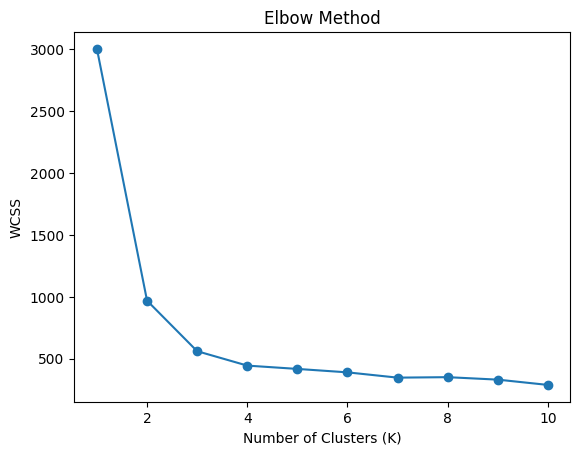

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

The elbow point appears around K = 3, where the decrease in WCSS slows down significantly.
This indicates that adding more clusters does not improve clustering much.

So, the optimal number of clusters is K = X.

3. K-Means Clustering

In [3]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

# Cluster centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0: Younger customers with low spending but frequent visits
Cluster 1: High spenders with large basket sizes (premium customers)
Cluster 2: Infrequent shoppers with moderate spending

----> This helps businesses target customers with personalized strategies.

4. Dimensionality Reduction with PCA 

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Create DataFrame
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Feature loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

loadings

Explained Variance Ratio:
[0.83560354 0.05568764]


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PC1 mainly represents overall spending behavior (high loadings from annual_spend, basket_size)
PC2 captures customer activity (like visits_per_month, days_since_last_visit)

So:

PC1 → Spending pattern
PC2 → Engagement level

5. Cluster Visualisation

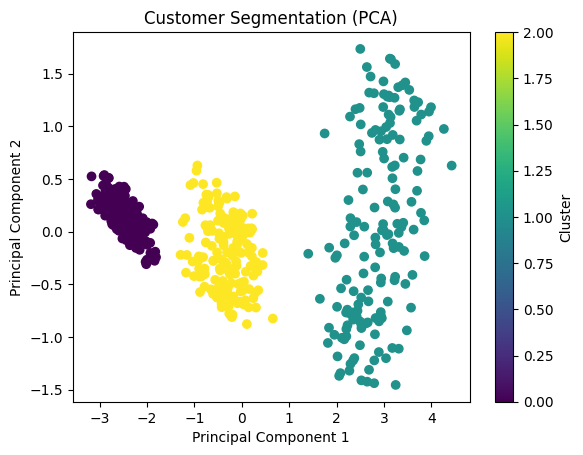

In [5]:
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['cluster'])
plt.title("Customer Segmentation (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster')
plt.show()